In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# --- Cài đặt TensorFlow ---
!pip install tensorflow numpy pandas librosa scikit-learn psutil matplotlib tqdm  keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 5.4 MB/s eta 0:00:00


In [ ]:
 # LSB
import os
import pandas as pd
import numpy as np
import joblib
import warnings
import time
import psutil
from datetime import datetime
import json
import sklearn
import librosa
import matplotlib.pyplot as plt
from tqdm import tqdm

# Thư viện TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Thư viện Scikit-learn (dùng cho metrics và splitting)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler # Dùng StandardScaler cho ảnh cũng OK
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# --- CẤU HÌNH CHÍNH ---
OUTPUT_DIR = '/content/drive/MyDrive/HK1-20252026/ClassifyStego'
COVER_FOLDER = '/content/drive/MyDrive/HK1-20252026/Steganography/Data/musdb18-hq'
STEGO_FOLDER = '/content/drive/MyDrive/HK1-20252026/ClassifyStego/data_model/lsb/Stego'

# Tạo các thư mục output
os.makedirs(os.path.join(OUTPUT_DIR, 'data_processed'), exist_ok=True)
os.makedirs(os.path.join(OUTPUT_DIR, 'LSB','CNN'), exist_ok=True)
os.makedirs(os.path.join(OUTPUT_DIR, 'reports'), exist_ok=True)

# --- Định nghĩa các tên file ---
SPECTROGRAM_FILE = os.path.join(OUTPUT_DIR, 'data_processed', 'lsb_spectrograms.npz') # File lưu spectrogram
MODEL_FILE_CNN_DEFAULT = os.path.join(OUTPUT_DIR,'LSB', 'CNN', 'cnn_model_default.keras') # Lưu model Keras
MODEL_FILE_CNN_TUNED = os.path.join(OUTPUT_DIR, 'LSB','CNN', 'cnn_model_tuned.keras')

TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")
JSON_REPORT_FILE_CNN_DEFAULT = os.path.join(OUTPUT_DIR, 'LSB', 'CNN', f'report_CNN_default_{TIMESTAMP}.json')
JSON_REPORT_FILE_CNN_TUNED = os.path.join(OUTPUT_DIR, 'LSB', 'CNN', f'report_CNN_tuned_{TIMESTAMP}.json')

MODEL_FILE_CNN_TUNED_KT = os.path.join(OUTPUT_DIR, 'LSB', 'CNN', 'cnn_model_keras_tuner.keras')
JSON_REPORT_FILE_CNN_TUNED_KT = os.path.join(OUTPUT_DIR, 'LSB', 'CNN', f'report_CNN_keras_tuner_{TIMESTAMP}.json')

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings('ignore', category=RuntimeWarning) # Bỏ qua cảnh báo skew/kurtosis nếu có

In [ ]:
def audio_to_melspectrogram(file_path, n_mels=128, fmax=8000, fixed_length=216):
    """Chuyển audio thành ảnh Mel Spectrogram (dB) với kích thước cố định."""
    try:
        y, sr = librosa.load(file_path, sr=None, duration=5.0) # Đọc 5 giây đầu
        if len(y) < 5 * sr: y = np.tile(y, int(np.ceil((5 * sr) / len(y))))
        y = y[:5 * sr]

        S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels, fmax=fmax)
        S_db = librosa.power_to_db(S, ref=np.max)

        # Cố định chiều dài (width) của spectrogram
        if S_db.shape[1] > fixed_length:
            S_db = S_db[:, :fixed_length]
        else:
            pad_width = fixed_length - S_db.shape[1]
            S_db = np.pad(S_db, pad_width=((0, 0), (0, pad_width)), mode='constant')

        return S_db
    except Exception as e:
        print(f"Lỗi tạo spectrogram cho {file_path}: {e}")
        return None

def load_spectrogram_data(cover_folder, stego_folder, spectrogram_file):
    """Tải hoặc tạo dữ liệu spectrogram."""
    if os.path.exists(spectrogram_file):
        print(f" Tải dữ liệu spectrogram từ file '{spectrogram_file}'...")
        data = np.load(spectrogram_file)
        return data['spectrograms'], data['labels']
    else:
        print(f" Không tìm thấy file spectrogram. Bắt đầu tạo...")
        spectrograms, labels, files_to_process = [], [], []
        # (Thu thập danh sách file như trước)
        for root, _, files in os.walk(cover_folder):
            for f in files:
                if f.endswith(('.wav', '.mp3', '.flac')): files_to_process.append({'path': os.path.join(root, f), 'label': 0})
        for root, _, files in os.walk(stego_folder):
            for f in files:
                if f.endswith(('.wav', '.mp3', '.flac')): files_to_process.append({'path': os.path.join(root, f), 'label': 1})

        for file_info in tqdm(files_to_process, desc="Đang tạo spectrogram"):
            spec = audio_to_melspectrogram(file_info['path'])
            if spec is not None:
                spectrograms.append(spec)
                labels.append(file_info['label'])

        X_spec = np.array(spectrograms)
        y_spec = np.array(labels)

        print(f"Lưu spectrogram vào file '{spectrogram_file}'...")
        np.savez_compressed(spectrogram_file, spectrograms=X_spec, labels=y_spec)
        return X_spec, y_spec

# --- Tải hoặc tạo dữ liệu ---
X_spectrograms, y_labels = load_spectrogram_data(COVER_FOLDER, STEGO_FOLDER, SPECTROGRAM_FILE)
print(f"\nTổng cộng {X_spectrograms.shape[0]} spectrogram sẵn sàng. Kích thước mỗi ảnh: {X_spectrograms.shape[1:]}")

# --- Chuẩn bị dữ liệu cho CNN ---
# Thêm chiều kênh màu (channel dimension)
X_spectrograms = X_spectrograms[..., np.newaxis]

# Chuẩn hóa giá trị pixel về [0, 1]
X_spectrograms = X_spectrograms / np.max(np.abs(X_spectrograms)) # Cách chuẩn hóa đơn giản

# Chia train/test
X_train_img, X_test_img, y_train, y_test = train_test_split(
    X_spectrograms, y_labels, test_size=0.2, random_state=42, stratify=y_labels
)

input_shape = X_train_img.shape[1:] # Lấy kích thước ảnh (height, width, channels)
print(f"Input shape cho CNN: {input_shape}")
print(f"Kích thước tập huấn luyện: {X_train_img.shape}")
print(f"Kích thước tập kiểm thử: {X_test_img.shape}")

✅ Tải dữ liệu spectrogram từ file '/content/drive/MyDrive/HK1-20252026/ClassifyStego/data_processed/lsb_spectrograms.npz'...

Tổng cộng 1500 spectrogram sẵn sàng. Kích thước mỗi ảnh: (128, 216)
Input shape cho CNN: (128, 216, 1)
Kích thước tập huấn luyện: (1200, 128, 216, 1)
Kích thước tập kiểm thử: (300, 128, 216, 1)


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import keras_tuner as kt
import time
import psutil
import json
import numpy as np
import pandas as pd
import joblib

# ==============================================================================
# PHẦN 3: HÀM XÂY DỰNG MODEL VÀ HÀM THỰC THI THỬ NGHIỆM
# ==============================================================================

# --- A. Hàm xây dựng model cho Keras Tuner ---
def build_model_for_tuner(hp):
    """Hàm xây dựng mô hình CNN với không gian tìm kiếm được mở rộng."""

    model = Sequential()
    model.add(tf.keras.layers.Input(shape=input_shape))

    # # === MỞ RỘNG KHÔNG GIAN FILTERS ===
    # # Thêm lựa chọn 128
    # hp_filters_1 = hp.Choice('filters_1', values=[32, 64, 128])
    # model.add(Conv2D(filters=hp_filters_1, kernel_size=(3, 3), activation='relu'))
    # model.add(BatchNormalization())
    # model.add(MaxPooling2D((2, 2)))

    # # === MỞ RỘNG KHÔNG GIAN FILTERS ===
    # # Thêm lựa chọn 256
    # hp_filters_2 = hp.Choice('filters_2', values=[64, 128, 256])
    # model.add(Conv2D(filters=hp_filters_2, kernel_size=(3, 3), activation='relu'))
    # model.add(BatchNormalization())
    # model.add(MaxPooling2D((2, 2)))

    # model.add(Flatten())

    # # === MỞ RỘNG KHÔNG GIAN DENSE ===
    # # Thêm lựa chọn 256
    # hp_dense_units = hp.Choice('dense_units', values=[64, 128, 256])
    # model.add(Dense(units=hp_dense_units, activation='relu'))

    # # Không gian Dropout của bạn đã tốt (0.2, 0.3, 0.4, 0.5)
    # hp_dropout = hp.Float('dropout', min_value=0.2, max_value=0.5, step=0.1)
    # model.add(Dropout(hp_dropout))

    # model.add(Dense(1, activation='sigmoid'))

    # # === CỰC KỲ QUAN TRỌNG: MỞ RỘNG LEARNING RATE ===
    # # Thêm 1e-5 (0.00001). Đây là giá trị quan trọng nhất.
    # hp_learning_rate = hp.Choice('learning_rate', values=[1e-3, 1e-4, 1e-5])


    hp_filters_1 = hp.Choice('filters_1', values=[32, 64])
    model.add(Conv2D(filters=hp_filters_1, kernel_size=(3, 3), activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2, 2)))


    hp_filters_2 = hp.Choice('filters_2', values=[64, 128])
    model.add(Conv2D(filters=hp_filters_2, kernel_size=(3, 3), activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2, 2)))

    model.add(Flatten())


    hp_dense_units = hp.Choice('dense_units', values=[64, 128])
    model.add(Dense(units=hp_dense_units, activation='relu'))


    hp_dropout = hp.Float('dropout', min_value=0.3, max_value=0.4, step=0.1)
    model.add(Dropout(hp_dropout))

    model.add(Dense(1, activation='sigmoid'))


    hp_learning_rate = hp.Choice('learning_rate', values=[ 1e-4, 1e-5])


    optimizer = Adam(learning_rate=hp_learning_rate)
    model.compile(optimizer=optimizer,
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

# --- B. Hàm chạy thử nghiệm CNN (cho bản mặc định) ---
def run_cnn_default_experiment(model_name, build_fn_params, model_file, report_file,
                               X_train, y_train, X_test, y_test, epochs=25, batch_size=32):
    """Hàm chạy thử nghiệm cho mô hình CNN với tham số CỐ ĐỊNH."""
    print("\n" + "="*60)
    print(f"BẮT ĐẦU QUY TRÌNH CHO: {model_name.upper()}")
    print("="*60)

    log_data = {}
    process = psutil.Process(os.getpid())
    start_time_model = time.time()

    print(f"\n Xây dựng và huấn luyện mô hình {model_name}...")

    # Xây dựng mô hình với các tham số được truyền vào
    # Tạo hàm build riêng cho bản default để tránh lỗi Keras Tuner
    def build_default_cnn(input_shape, conv1_filters, conv2_filters, dense_units, dropout_rate, learning_rate):
        """Hàm xây dựng kiến trúc CNN với tham số CỐ ĐỊNH."""
        model = Sequential([
            # Thêm lớp Input riêng biệt
            Input(shape=input_shape),

            Conv2D(conv1_filters, (3, 3), activation='relu'), # Bỏ input_shape ở đây
            BatchNormalization(),
            MaxPooling2D((2, 2)),

            Conv2D(conv2_filters, (3, 3), activation='relu'),
            BatchNormalization(),
            MaxPooling2D((2, 2)),

            Flatten(),
            Dense(dense_units, activation='relu'),
            Dropout(dropout_rate),
            Dense(1, activation='sigmoid')
        ])
        optimizer = Adam(learning_rate=learning_rate)
        model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
        return model

    model = build_default_cnn(input_shape=X_train.shape[1:], **build_fn_params)
    print(model.summary())

    # Huấn luyện
    mem_before_train = process.memory_info().rss
    start_time_train = time.time()
    early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size,
                        validation_data=(X_test, y_test), callbacks=[early_stopping], verbose=1)
    training_duration = time.time() - start_time_train
    mem_after_train = process.memory_info().rss
    training_memory_increase_mb = (mem_after_train - mem_before_train) / (1024 * 1024)
    print(f"Huấn luyện hoàn tất sau {training_duration:.2f} giây.")

    actual_params = {
        'epochs_run': len(history.history['loss']), 'batch_size': batch_size,
        'optimizer_config': model.optimizer.get_config(), 'loss_function': model.loss.__name__ if hasattr(model.loss, '__name__') else str(model.loss),
        'model_architecture_params': build_fn_params
    }
    log_data['training_info'] = {
        'status': f'Trained model ({model_name})', 'model_class': 'Sequential_CNN',
        'training_duration_seconds': round(training_duration, 2),
        'training_memory_increase_mb': round(training_memory_increase_mb, 2),
        'all_model_params': actual_params
    }
    model.save(model_file)
    print(f"Đã lưu mô hình Keras vào file: {model_file}")

    # Đánh giá hiệu năng (code giữ nguyên như trước)
    print(f"\n--- Đánh giá hiệu năng mô hình {model_name} ---")
    start_time_pred_train = time.time(); y_train_pred_proba = model.predict(X_train)
    y_train_pred = (y_train_pred_proba > 0.5).astype(int).flatten(); pred_train_duration = time.time() - start_time_pred_train
    train_accuracy = accuracy_score(y_train, y_train_pred)
    start_time_pred_test = time.time(); y_test_pred_proba = model.predict(X_test)
    y_test_pred = (y_test_pred_proba > 0.5).astype(int).flatten(); pred_test_duration = time.time() - start_time_pred_test
    test_accuracy = accuracy_score(y_test, y_test_pred)

    print(f"\nĐộ chính xác trên tập Train: {train_accuracy:.4f}")
    print("Báo cáo chi tiết trên tập Train:"); print(classification_report(y_train, y_train_pred, target_names=['Cover (0)', 'Stego (1)']))
    print(f"\nĐộ chính xác trên tập Test: {test_accuracy:.4f}")
    print("Báo cáo chi tiết trên tập Test:"); print(classification_report(y_test, y_test_pred, target_names=['Cover (0)', 'Stego (1)']))
    print(f"Thời gian dự đoán trên tập Test: {pred_test_duration:.4f} giây")

    ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred, display_labels=['Cover (0)', 'Stego (1)'], cmap=plt.cm.Blues)
    plt.title(f"Ma trận nhầm lẫn trên tập Test ({model_name})"); plt.show()

    execution_time = time.time() - start_time_model
    log_data['evaluation_results'] = {
        'train_set': {'accuracy': train_accuracy, 'classification_report': classification_report(y_train, y_train_pred, output_dict=True), 'prediction_duration_seconds': round(pred_train_duration, 4)},
        'test_set': {'accuracy': test_accuracy, 'classification_report': classification_report(y_test, y_test_pred, output_dict=True), 'prediction_duration_seconds': round(pred_test_duration, 4)}
    }
    log_data['run_info'] = {'timestamp': datetime.now().isoformat(), 'execution_duration_seconds': round(execution_time, 2)}

    # Serializer an toàn cho JSON
    def default_serializer(o):
        if isinstance(o, (np.int_, np.intc, np.intp, np.int8, np.int16, np.int32, np.int64, np.uint8, np.uint16, np.uint32, np.uint64)): return int(o)
        elif isinstance(o, (np.float_, np.float16, np.float32, np.float64)): return float(o)
        elif isinstance(o,(np.ndarray,)): return o.tolist()
        try: return str(o) # Thử chuyển đổi sang string
        except Exception: return repr(o) # Nếu không được, dùng repr()

    with open(report_file, 'w', encoding='utf-8') as f:
        json.dump(log_data, f, indent=4, ensure_ascii=False, default=default_serializer)
    print(f" Đã lưu báo cáo chi tiết vào file: {report_file}")




BẮT ĐẦU QUY TRÌNH CHO: CNN_DEFAULT

⚠️ Xây dựng và huấn luyện mô hình CNN_Default...


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 126, 214, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 126, 214, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 63, 107, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 61, 105, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 61, 105, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 30, 52, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 99840)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │    12,779,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,798,977 (48.82 MB)

 Trainable params: 12,798,785 (48.82 MB)

 Non-trainable params: 192 (768.00 B)

None
Epoch 1/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 12s 131ms/step - accuracy: 0.5953 - loss: 0.8441 - val_accuracy: 0.4633 - val_loss: 0.6945
Epoch 2/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.6627 - loss: 0.5875 - val_accuracy: 0.5000 - val_loss: 0.7073
Epoch 3/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.6889 - loss: 0.5230 - val_accuracy: 0.5000 - val_loss: 0.7237
Epoch 4/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.6970 - loss: 0.4825 - val_accuracy: 0.5000 - val_loss: 0.7881
Epoch 5/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.6977 - loss: 0.4784 - val_accuracy: 0.5000 - val_loss: 0.9104
Epoch 6/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.7052 - loss: 0.4850 - val_accuracy: 0.5000 - val_loss: 0.8998
Epoch 7/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.6831 - loss: 0.4845 - val_accuracy: 0.5000 - val_loss: 0.8576
Epoch 8/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.7011 - loss: 0.4605 - val_accuracy: 0.5

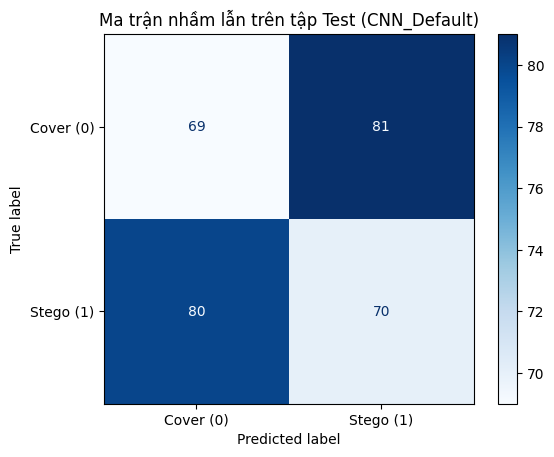

📝 Đã lưu báo cáo chi tiết vào file: /content/drive/MyDrive/HK1-20252026/ClassifyStego/LSB/CNN/report_CNN_default_20251122_131522.json


In [ ]:


# --- A. Chạy CNN với tham số gần MẶC ĐỊNH ---
default_cnn_params = {
    'conv1_filters': 32, 'conv2_filters': 64, 'dense_units': 128,
    'dropout_rate': 0.25, 'learning_rate': 0.00001
}
run_cnn_default_experiment(
    model_name='CNN_Default', build_fn_params=default_cnn_params,
    model_file=MODEL_FILE_CNN_DEFAULT, report_file=JSON_REPORT_FILE_CNN_DEFAULT,
    X_train=X_train_img, y_train=y_train, X_test=X_test_img, y_test=y_test,
    epochs=30
)

In [ ]:

TUNER_LOG_FILE_CNN = os.path.join(OUTPUT_DIR, 'LSB', 'CNN', f'tuner_log_CNN_{TIMESTAMP}.csv')
print("\n" + "="*60)
print("BẮT ĐẦU QUY TRÌNH TINH CHỈNH CNN VỚI KERAS TUNER")
print("="*60)

# Ghi lại thời gian và bộ nhớ bắt đầu
start_time_tuner = time.time()
log_data_tuner = {}
process = psutil.Process(os.getpid())
mem_before_train = process.memory_info().rss

# --- Khởi tạo Tuner (RandomSearch) ---
tuner = kt.RandomSearch(
    build_model_for_tuner,
    objective='val_accuracy',
    max_trials=10,  # Thử 10 tổ hợp
    executions_per_trial=1, # Chạy 1 lần cho mỗi trial để nhanh hơn
    directory=os.path.join(OUTPUT_DIR, 'keras_tuner_dir'), # Thư mục tạm
    project_name=f'cnn_tuning_{TIMESTAMP}'
)

tuner.search_space_summary() # In ra không gian tìm kiếm

# --- Bắt đầu quá trình tìm kiếm ---
print("\nBắt đầu quá trình tìm kiếm siêu tham số...")
# Tăng patience (số epoch chờ) để tránh dừng quá sớm
early_stopping = EarlyStopping(monitor='val_loss', patience=10)
tuner.search(X_train_img, y_train,
             epochs=30, # Số epoch tối đa cho mỗi lần thử
             validation_data=(X_test_img, y_test),
             batch_size=32,
             callbacks=[early_stopping])

# --- Lấy kết quả tốt nhất ---
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print("\nSiêu tham số tốt nhất tìm được:"); print(best_hps.values)

# --- Huấn luyện lại mô hình tốt nhất ---
print("\nHuấn luyện lại mô hình tốt nhất với dữ liệu đầy đủ...")
best_model_tuned = tuner.hypermodel.build(best_hps) # Xây dựng model từ HPs tốt nhất

# Đo thời gian và bộ nhớ cho lần huấn luyện cuối cùng
start_time_final_train = time.time()
history = best_model_tuned.fit(X_train_img, y_train,
                               epochs=30, # Train nhiều hơn
                               batch_size=32,
                               validation_data=(X_test_img, y_test),
                               callbacks=[EarlyStopping(monitor='val_loss', patience=10)],
                               verbose=1)
final_training_duration = time.time() - start_time_final_train
mem_after_train = process.memory_info().rss
training_memory_increase_mb = (mem_after_train - mem_before_train) / (1024 * 1024)
print(f"Huấn luyện cuối cùng hoàn tất sau {final_training_duration:.2f} giây.")

# Lưu model Keras
best_model_tuned.save(MODEL_FILE_CNN_TUNED_KT)
print(f"Đã lưu mô hình Keras Tuner vào file: {MODEL_FILE_CNN_TUNED_KT}")

# ==============================================================================
# --- LƯU LOG CHI TIẾT TẤT CẢ CÁC TRIALS TỪ KERAS TUNER (Giống GridSearchCV) ---
# ==============================================================================
print("\nĐang thu thập và lưu log chi tiết của Keras Tuner...")
all_trials = tuner.oracle.trials.values()
results_list = []
for trial in all_trials:
    trial_data = {}
    trial_data['trial_id'] = trial.trial_id
    # Đảm bảo score là số (có thể là None nếu trial bị lỗi)
    trial_data['score'] = trial.score if trial.score is not None else np.nan

    # Lấy tất cả siêu tham số đã thử
    for hp_name, hp_value in trial.hyperparameters.values.items():
        trial_data[f'param_{hp_name}'] = hp_value

    results_list.append(trial_data)

if results_list:
    tuner_log_df = pd.DataFrame(results_list)
    tuner_log_df = tuner_log_df.sort_values(by='score', ascending=False) # Xếp hạng

    # Lưu ra file CSV
    tuner_log_df.to_csv(TUNER_LOG_FILE_CNN, index=False)
    print(f" Đã lưu log chi tiết của Tuner (tất cả {len(tuner_log_df)} trials) vào file: {TUNER_LOG_FILE_CNN}")
else:
    print(" Không tìm thấy kết quả trial nào để lưu.")
# ==============================================================================
# --- KẾT THÚC PHẦN LƯU LOG CSV ---
# ==============================================================================


# --- ĐÁNH GIÁ VÀ LƯU BÁO CÁO JSON CUỐI CÙNG ---
print(f"\n--- Đánh giá hiệu năng mô hình CNN (Keras Tuner) ---")
# Đo thời gian dự đoán
start_time_pred_train = time.time(); y_train_pred_proba = best_model_tuned.predict(X_train_img)
y_train_pred = (y_train_pred_proba > 0.5).astype(int).flatten(); pred_train_duration = time.time() - start_time_pred_train
train_accuracy = accuracy_score(y_train, y_train_pred)

start_time_pred_test = time.time(); y_test_pred_proba = best_model_tuned.predict(X_test_img)
y_test_pred = (y_test_pred_proba > 0.5).astype(int).flatten(); pred_test_duration = time.time() - start_time_pred_test
test_accuracy = accuracy_score(y_test, y_test_pred)

# In báo cáo chi tiết
print(f"\nĐộ chính xác trên tập Train: {train_accuracy:.4f}")
print("Báo cáo chi tiết trên tập Train:"); print(classification_report(y_train, y_train_pred, target_names=['Cover (0)', 'Stego (1)']))


Trial 10 Complete [00h 00m 33s]
val_accuracy: 0.6766666769981384

Best val_accuracy So Far: 0.7099999785423279
Total elapsed time: 00h 07m 12s

Siêu tham số tốt nhất tìm được:
{'filters_1': 64, 'filters_2': 64, 'dense_units': 64, 'dropout': 0.3, 'learning_rate': 0.0001}

Huấn luyện lại mô hình tốt nhất với dữ liệu đầy đủ...
Epoch 1/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 10s 142ms/step - accuracy: 0.5951 - loss: 2.0999 - val_accuracy: 0.4567 - val_loss: 0.6859
Epoch 2/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.6375 - loss: 1.2537 - val_accuracy: 0.5000 - val_loss: 0.9782
Epoch 3/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.6677 - loss: 0.7908 - val_accuracy: 0.5000 - val_loss: 1.3364
Epoch 4/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.6678 - loss: 0.6071 - val_accuracy: 0.5000 - val_loss: 2.1436
Epoch 5/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.6787 - loss: 0.5686 - val_accuracy: 0.5000 - val_loss: 2.6722
Epoch 6/30
38/38 ━━━━━━━━━━━━━━━━━━━━